# Credit Card Customer Segmentation using KMeans Clustering

**Author:** Monica Qiao

**Tools Used:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

**Machine Learning Algorithm:** KMeans Clustering

**Learning Type:** Unsupervised Learning

## 1. Project Overview

### Objective

The objective of this project is to identify meaningful customer segments based on credit card usage behavior using KMeans Clustering, an unsupervised machine learning algorithm.

Unlike supervised learning, the dataset does not contain predefined customer categories. Instead, the algorithm discovers hidden patterns by grouping customers with similar financial behaviors.

The results can help financial institutions better understand their customers and support business decisions such as targeted marketing, customer retention, and risk management.

---

### Dataset

The dataset contains information for 8,950 credit card customers, including:

Balance
Purchase amount
Cash advances
Credit limit
Payment behavior
Purchase frequency
Minimum payments
Percentage of full payments
Customer tenure

---

### Machine Learning Approach

Algorithm: KMeans Clustering
Learning Type: Unsupervised Learning
Number of Features Used: 17
Final Number of Customers After Cleaning: 8,636


## 2. Import Libraries

In this section, the required Python libraries are imported for data manipulation, visualization, preprocessing, clustering, dimensionality reduction, and model evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 3. Load Dataset

The dataset is loaded into a pandas DataFrame for exploration and analysis.

import os
os.listdir()

df = pd.read_csv("CC GENERAL.csv")

Display the first five rows:

df.head()

Check the dataset dimensions:

df.shape

Display the dataset information:

df.info()

In [2]:
import os
os.listdir()

['credit_card_customer_segmentation.ipynb',
 '.DS_Store',
 'CC GENERAL.csv',
 'README.md',
 '.gitignore',
 'credit_card_customers_clustered.csv',
 '.ipynb_checkpoints',
 '.git']

In [3]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")

# Display the first five rows of the dataset to understand its structure.
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
#Check the number of rows and columns in the dataset.
df.shape

(8950, 18)

In [5]:
#Display the dataset information, including data types and missing values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

**df.info() shows the data types and missing values of CREDIT_LIMIT and MINIMUM_PAYMENTS**

## 4. Initial Data Exploration

Before cleaning the data, it is important to understand the variables and identify potential data quality issues.

The dataset contains:

- 18 columns
- 17 numerical variables
- 1 identifier column (`CUST_ID`)

The identifier column is used only to uniquely identify customers and does not contain behavioral information, so it will not be used for clustering.

The dataset also contains missing values, which need to be addressed before applying machine learning algorithms.

## 5. Data Cleaning

In this step, we clean the dataset by handling missing values and removing unnecessary columns.

KMeans clustering requires a complete numerical dataset, so missing values must be removed or imputed before modeling.

In [6]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Since the number of missing values is small compared to the dataset size, we remove them using `dropna()`.

In [7]:
# remove the missing values, MINIMUM_PAYMENTS 313/8950 = 3.5% only, CREDIT_LIMIT 1/8950=0.01% only

df=df.dropna()
df.shape

(8636, 18)

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,3.313918,15.033233,4522.091030,1784.478099,864.304943,0.159304,11.534391
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,6.912506,25.180468,3659.240379,2909.810090,2372.566350,0.296271,1.310984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.559237,169.163545,0.000000,12.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.675701,312.452292,0.000000,12.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.142090,825.496463,0.166667,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


Next, we remove the `CUST_ID` column because it is only an identifier and does not contain behavioral information useful for clustering.

In [9]:

df_model = df.drop("CUST_ID",axis=1)

# or we can use df.drop(columns = ["CUST_ID])

## 6. Feature Scaling

KMeans is a distance-based algorithm, which means it is sensitive to the scale of the features.

For example:
- PURCHASES can be in thousands
- PRC_FULL_PAYMENT is between 0 and 1

To ensure all features contribute equally, we apply **StandardScaler** to normalize the data.

In [10]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)

## 7. Elbow Method

The Elbow Method helps determine the optimal number of clusters (K).

We run KMeans for different values of K and observe the inertia (within-cluster error).

The optimal K is chosen where the improvement starts to slow down ("elbow point").

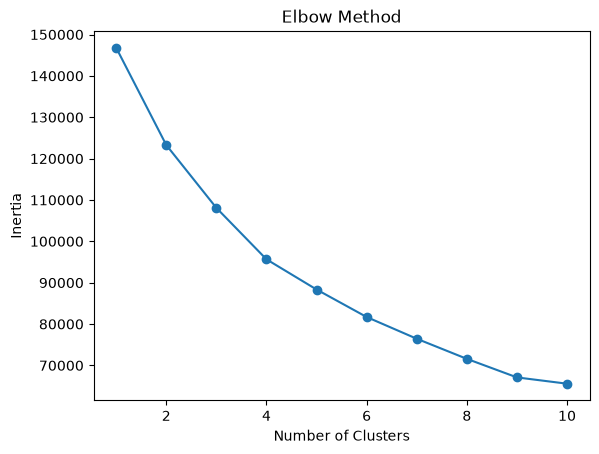

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Based on the Elbow Method, the optimal number of clusters is chosen as:

### 👉 K = 4

This is where the reduction in inertia starts to slow significantly.

## 8. KMeans Clustering

Now that we have selected the optimal number of clusters (K = 4), we apply the KMeans algorithm to group customers based on their financial behavior.

Each customer will be assigned a cluster label representing their behavioral segment.

We create a new dataset that includes the cluster labels for analysis.

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)

df_model = df.drop(columns=["CUST_ID"])
df_clustered = df_model.copy()
df_clustered["Cluster"] = labels

In [13]:
df_clustered.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE', 'Cluster'],
      dtype='str')

In [14]:
df_clustered["Cluster"].value_counts()

Cluster
2    3805
0    3281
3    1156
1     394
Name: count, dtype: int64

## 9. Model Evaluation

### 9.1 Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

- +1 → well separated clusters  
- 0 → overlapping clusters  
- -1 → incorrect clustering

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.197


In [16]:
# Compare silhouette scores across K to test whether K=4 is the best choice
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
    print(f"K={k}: silhouette = {silhouette_score(scaled_data, km.labels_):.3f}")


K=2: silhouette = 0.208
K=3: silhouette = 0.247
K=4: silhouette = 0.197
K=5: silhouette = 0.192
K=6: silhouette = 0.208
K=7: silhouette = 0.220
K=8: silhouette = 0.227
K=9: silhouette = 0.232
K=10: silhouette = 0.214


The silhouette score obtained is relatively low (0.192 to 0.247), which is common in real-world customer datasets.

Customer behavior data often overlaps, making perfect separation difficult.

However, the clusters still provide useful business insights.

### Choosing the Number of Clusters

The **Silhouette Score** peaks at **K=3 (0.247)**, while **K=4** scores **0.197**—the **second-lowest Silhouette Score** among the tested values. This indicates that K=3 produces better-separated clusters from a purely mathematical perspective.

However, K=3 merges **5,857 purchasing customers** into a single broad segment, masking important differences in spending behavior. In contrast, K=4 separates this population into **High-Value (394)**, **Regular Active (3,281)**, and **Low-Activity (3,805)** customers, enabling more targeted business actions. The modest reduction in clustering quality is therefore outweighed by the improvement in business interpretability.

Importantly, **the cash-advance segment is robust to the choice of K**. Under K=3, a similar segment still emerges (**1,567 customers**, **$3,881** average cash advance, **$4,002** average balance), demonstrating that the project's primary business finding is not an artifact of selecting four clusters.

### 9.2 PCA Visualization

The dataset originally has 17 features, which cannot be visualized directly.

We use PCA (Principal Component Analysis) to reduce the data to 2 dimensions for visualization purposes.

In [17]:
#Apply PCA

from sklearn.decomposition import PCA

# Reduce the scaled data from 17 dimensions to 2
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [18]:
#create dataframe for plotting
import pandas as pd

pca_df = pd.DataFrame({
    "PC1": pca_data[:, 0],
    "PC2": pca_data[:, 1],
    "Cluster": labels
})

pca_df.head()

,PC1,PC2,Cluster
0,-1.696395,-1.122584,2
1,-1.215681,2.435638,3
2,0.935853,-0.385202,0
3,-1.614638,-0.724586,2
4,0.223701,-0.783610,0


In [19]:
pca_df["Cluster"].value_counts()

Cluster
2    3805
0    3281
3    1156
1     394
Name: count, dtype: int64

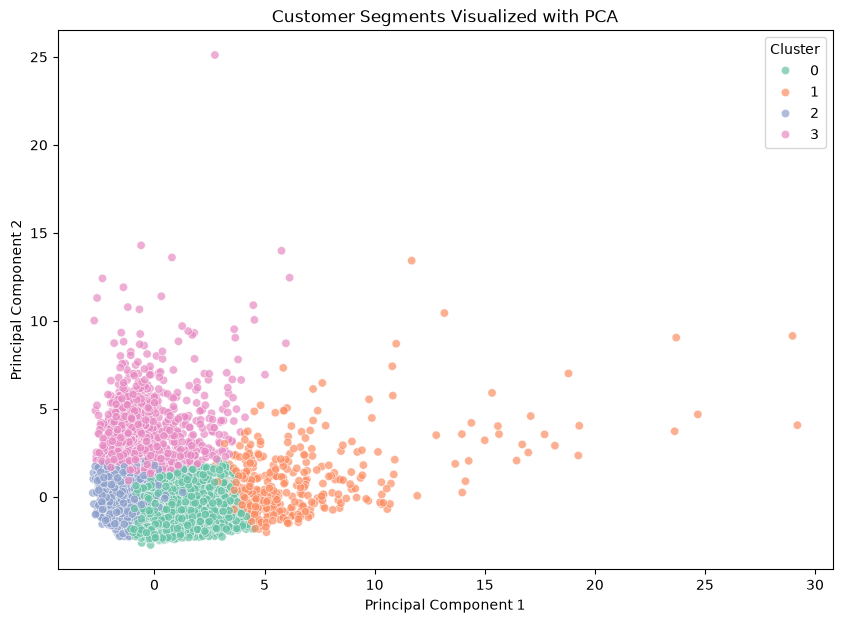

In [20]:
#plot clusters
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [21]:
#how much information PCA keeps
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

[0.27231177 0.20374308]
Total explained variance: 0.47605484578862833


The first two principal components explain approximately **47.6% of the variance**.

This means that while some information is lost during dimensionality reduction, the 2D visualization still provides a meaningful view of the cluster structure.

PCA reduced the 17 standardized features to two principal components for visualization. The first two components explained approximately 47.6% of the total variance, providing a useful two-dimensional representation of the customer segments. Although some information is lost in the reduction process, the visualization helps illustrate the overall cluster structure.

## 10. Customer Segment Interpretation

Now we analyze each cluster by looking at the average values of all features.

This helps us understand the behavior of each customer segment.

In [22]:
df_clustered.groupby("Cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,913.099184,0.946169,1264.675431,611.072630,653.884203,218.409256,0.887404,0.302467,0.713691,0.043817,0.815910,22.511429,4254.075054,1373.189779,649.316887,0.274334,11.601036
1,3586.147809,0.986840,7816.070736,5194.559518,2623.034061,658.230083,0.944589,0.737344,0.786971,0.070831,2.098985,90.347716,9775.380711,7454.041676,2016.140976,0.291842,11.949239
2,1061.245064,0.818901,273.943703,210.942878,63.279848,606.661232,0.174488,0.087724,0.083122,0.119162,2.211038,2.997898,3259.159877,1013.575184,573.842255,0.084056,11.479106
3,4655.121148,0.969212,505.501029,319.814377,185.774602,4585.995163,0.290473,0.139730,0.187859,0.487255,14.448097,7.753460,7649.268638,3556.895507,2037.975309,0.035326,11.385813


Based on the cluster averages, we can interpret customer behavior patterns and assign meaningful business labels to each segment.

### Cluster 0 — Regular Active Customers

- Moderate purchases  
- Regular usage  
- Balanced credit behavior  

These are stable regular users of credit cards.

### Cluster 1 — High-Value Customers

- Very high purchases  
- High credit limit  
- High repayments  
- Frequent usage

These are the most valuable customers for the bank.

### Cluster 2 — Low-Activity Customers

- Low purchases  
- Low frequency  
- Low engagement  

These customers rarely use their credit cards.

### Cluster 3 — Cash Advance Users

- High cash advances  
- Higher balances  
- Lower repayment behavior  

These customers rely heavily on cash withdrawals instead of purchases.

## 11. Business Recommendations

Based on the customer segments, we can design targeted strategies for each group.

| Cluster | Customer Type | Business Strategy |
|--------|---------------|------------------|
| 0 | Regular Active Customers | Offer cashback and reward programs |
| 1 | High-Value Customers | Provide premium cards and loyalty benefits |
| 2 | Low-Activity Customers | Increase engagement with promotions |
| 3 | Cash Advance Users | Monitor risk and encourage responsible usage |

These recommendations help improve:

- Customer retention  
- Revenue growth  
- Risk management  
- Personalized marketing strategies  

## 12. Conclusion

This project successfully applied KMeans clustering to segment credit card customers based on their financial behavior.

We followed a full machine learning workflow:

- Data cleaning  
- Feature scaling  
- Optimal cluster selection (Elbow Method)  
- KMeans clustering  
- Model evaluation (Silhouette Score + PCA)  
- Business interpretation  

Although the silhouette score indicates moderate separation, the clusters still provide meaningful insights into customer behavior.

### Key Outcome

We identified four distinct customer segments that can be used for:

- Targeted marketing  
- Customer retention strategies  
- Credit risk analysis  
- Product personalization  

This demonstrates the value of unsupervised learning in discovering hidden patterns in real-world financial data.

In [23]:
# Export the clustered data with customer IDs and cluster assignments
df_with_clusters = df.copy()  # Original df includes CUST_ID
df_with_clusters["Cluster"] = labels

# Save to CSV
df_with_clusters.to_csv("credit_card_customers_clustered.csv", index=False)
print("✓ File saved: credit_card_customers_clustered.csv")

✓ File saved: credit_card_customers_clustered.csv
